# Paris Commune Repression: Statistical Analysis Notebook

This notebook explores archival records for 41,375 individuals prosecuted after the Paris Commune. It combines descriptive work, logistic regression, event-history analysis, spatial aggregation, battalion composition, and robustness checks to address questions about selective repression and its social and spatial structure.

Run the cells from top to bottom. Several sections include optional branches that will use survival or spatial libraries if they are installed; otherwise, the notebook falls back to simpler but still interpretable models.

In [4]:
# Notebook setup

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

try:
    import geopandas as gpd
except Exception:
    gpd = None

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlepad"] = 12


def normalize_text(value):
    if pd.isna(value):
        return ""
    return str(value).lower().strip()


def classify_occupational_class(row):
    text = " ".join(
        normalize_text(row.get(col))
        for col in ["Branche", "Type d'activité", "Profession civile"]
    )
    if not text.strip():
        return "unknown"

    professional_patterns = [
        r"\b(avocat|docteur|médecin|medecin|professeur|ingénieur|ingenieur|architecte|journaliste|notaire|magistrat|pharmacien|avoué|commissaire)\b",
    ]
    white_collar_patterns = [
        r"\b(commis|employé|employe|bureau|comptable|caissier|négociant|negociant|vendeur|clerc|secrétaire|secretaire)\b",
    ]
    skilled_patterns = [
        r"\b(ouvrier|artisan|tailleur|menuis|charpent|serrurier|imprimeur|cordonn|maçon|macon|peintre|typograph|forgeron|ébénist|ebenist|blanchiss|hatter|shoemaker|mécanicien|mecanicien|passementier|ébéniste)\b",
    ]
    unskilled_patterns = [
        r"\b(man[œoe]uvre|journalier|journali[èe]r|domestique|porteur|charretier|terrassier|débardeur|debardeur|garçon|garcon|journelier)\b",
    ]

    if any(re.search(pattern, text) for pattern in professional_patterns):
        return "professional"
    if any(re.search(pattern, text) for pattern in white_collar_patterns):
        return "white_collar"
    if any(re.search(pattern, text) for pattern in skilled_patterns):
        return "skilled_worker"
    if any(re.search(pattern, text) for pattern in unskilled_patterns):
        return "unskilled_worker"
    return "unknown"


def classify_geo_quality(row):
    confidence = row.get("confidence_score")
    match_type = normalize_text(row.get("match_type"))
    if pd.isna(confidence):
        return "low"
    if confidence >= 0.85 and match_type in {"housenumber", "street"}:
        return "high"
    return "low"


def rank_to_band(rank_value):
    text = normalize_text(rank_value)
    if not text:
        return "unknown"
    if any(term in text for term in ["soldat", "gard", "fusilier", "simple", "canonnier"]):
        return "low"
    if any(term in text for term in ["caporal", "sergent", "adjudant", "brigadier"]):
        return "middle"
    if any(term in text for term in ["chef", "lieutenant", "capitaine", "commandant", "colonel", "major", "officier"]):
        return "high"
    return "unknown"

## Section 1: Data Overview & Construction of Key Variables

**Research question:**
> What does the archive contain, and how should we operationalise age, occupation, repression timing, geocoding quality, and special targeting before moving to the model-based sections?

This section establishes the sample size, shows the pattern of missingness, and then constructs the derived variables used in the later analyses. The coding rules are deliberately transparent so that they can be revised if a reader disagrees with a particular classification decision.

Loaded 41,375 rows and 39 columns


,Profile_URL,Raw_Bio_Text,Lieu de naissance,Date de naissance déclarée,Âge déclaré,Âge calculé au 31 mai 1871,État civil,Père,Mère,Adresse,...,add_house_number,add_street_raw,add_street,add_quartier,age,arrondissement,latitude,longitude,confidence_score,match_type
0,https://communards-1871.fr/index.php?page=fich...,Aab – Pierre Eugène Informations personnelles ...,"Paris, Seine",25/04/1835,36 ans,36 ans,célibataire ou en concubinage - 1 enfant(s) dé...,Jacques,Chocat Joséphine,Paris - Seine 38 Rue Montreuil (de) (quartie...,...,38,Rue Montreuil (de),Rue deMontreuil,Sainte Marguerite,36.0,11.0,48.889437,2.333749,0.481985,housenumber
1,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Adr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Paris - Seine,...,NaN,Paris - Seine,Paris - Seine,NaN,NaN,NaN,48.854446,2.336780,0.373809,street
2,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Lie...,"Lembeye, Pyrénées (Basses)",11/10/1835,36 ans,36 ans,marié(e),Dominique,Lavallière Bernarde,Paris - Seine 17 Route Asnières (d’) (quarti...,...,17,Route Asnières (d’),Route d’Asnières,Plaine de Monceaux,36.0,17.0,47.868098,-0.268180,0.514968,housenumber
3,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Lie...,"Tarbes, Pyrénées (Hautes)",03/10/1854,18 ans,17 ans,célibataire ou en concubinage,Pierre,Catherine,Paris - Seine 64 Avenue Clichy (de) (quartie...,...,64,Avenue Clichy (de),Avenue deClichy,Epinettes,17.0,17.0,48.827525,2.379933,0.636295,housenumber
4,https://communards-1871.fr/index.php?page=fich...,Abadie – Ismaël Isaac Informations personnelle...,"Vierzon, Cher",20/06/1820,NaN,51 ans,NaN,NaN,NaN,Paris - Seine 17 Rue Moreau (quartier Quinze...,...,17,Rue Moreau,Rue Moreau,Quinze Vingts,51.0,12.0,48.850171,2.372782,0.652525,housenumber



Missingness summary


,missing_count,missing_share
Précédemment inculpé à la suite des événements de Juin 1848 accès à la fiche du site dédié,41375,1.000000
Communard particulièrement recherché par les autorités (motif),41100,0.993353
Profession militaire,40520,0.979335
Autre fonction pendant la Commune,40434,0.977257
Marques,39124,0.945595
Archives nationales d’Outre-mer,37272,0.900834
Fonction pendant la Commune,36267,0.876544
"Archives nationales, rapports de grâce",35000,0.845921
"Archives nationales, dossiers de grâce",31963,0.772520
État civil,28568,0.690465


/var/folders/zp/r_synnss3dnc2lgwfbyr07h80000gn/T/ipykernel_14044/389630992.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


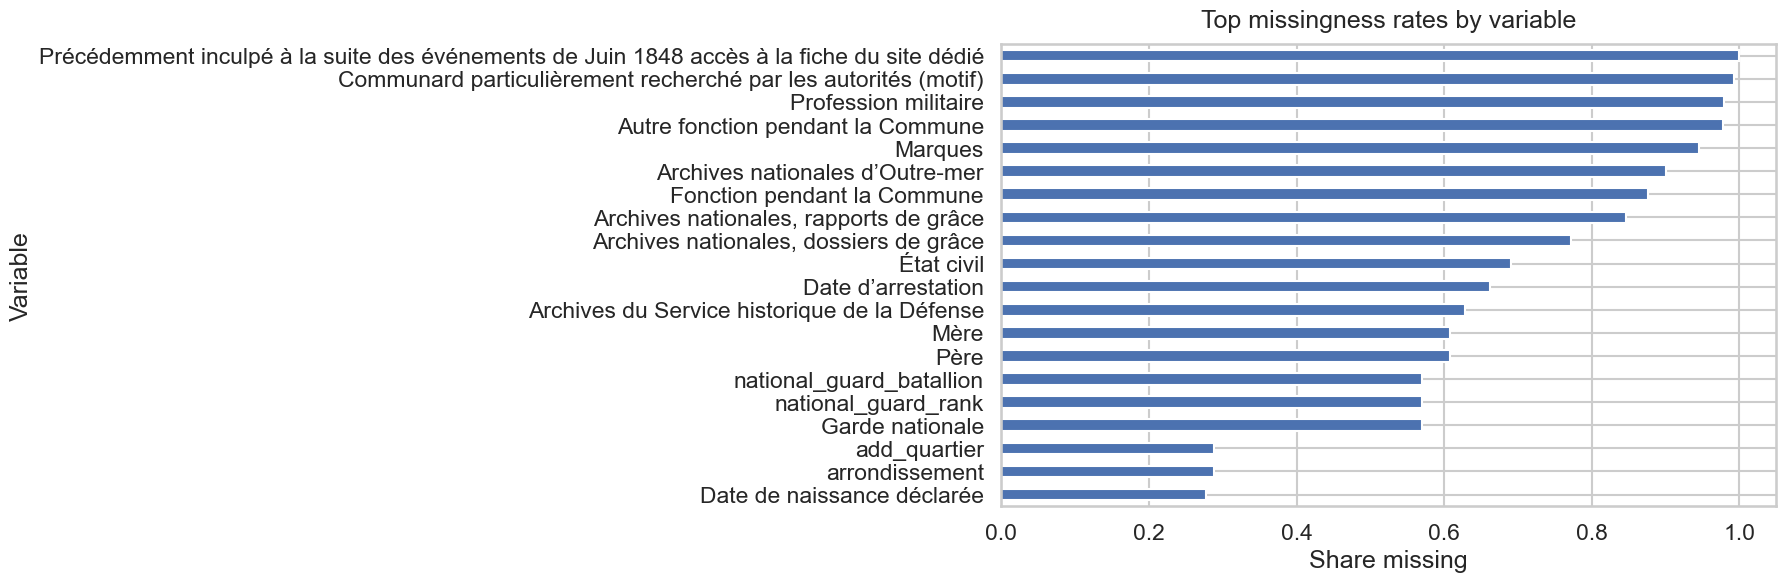

/var/folders/zp/r_synnss3dnc2lgwfbyr07h80000gn/T/ipykernel_14044/389630992.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


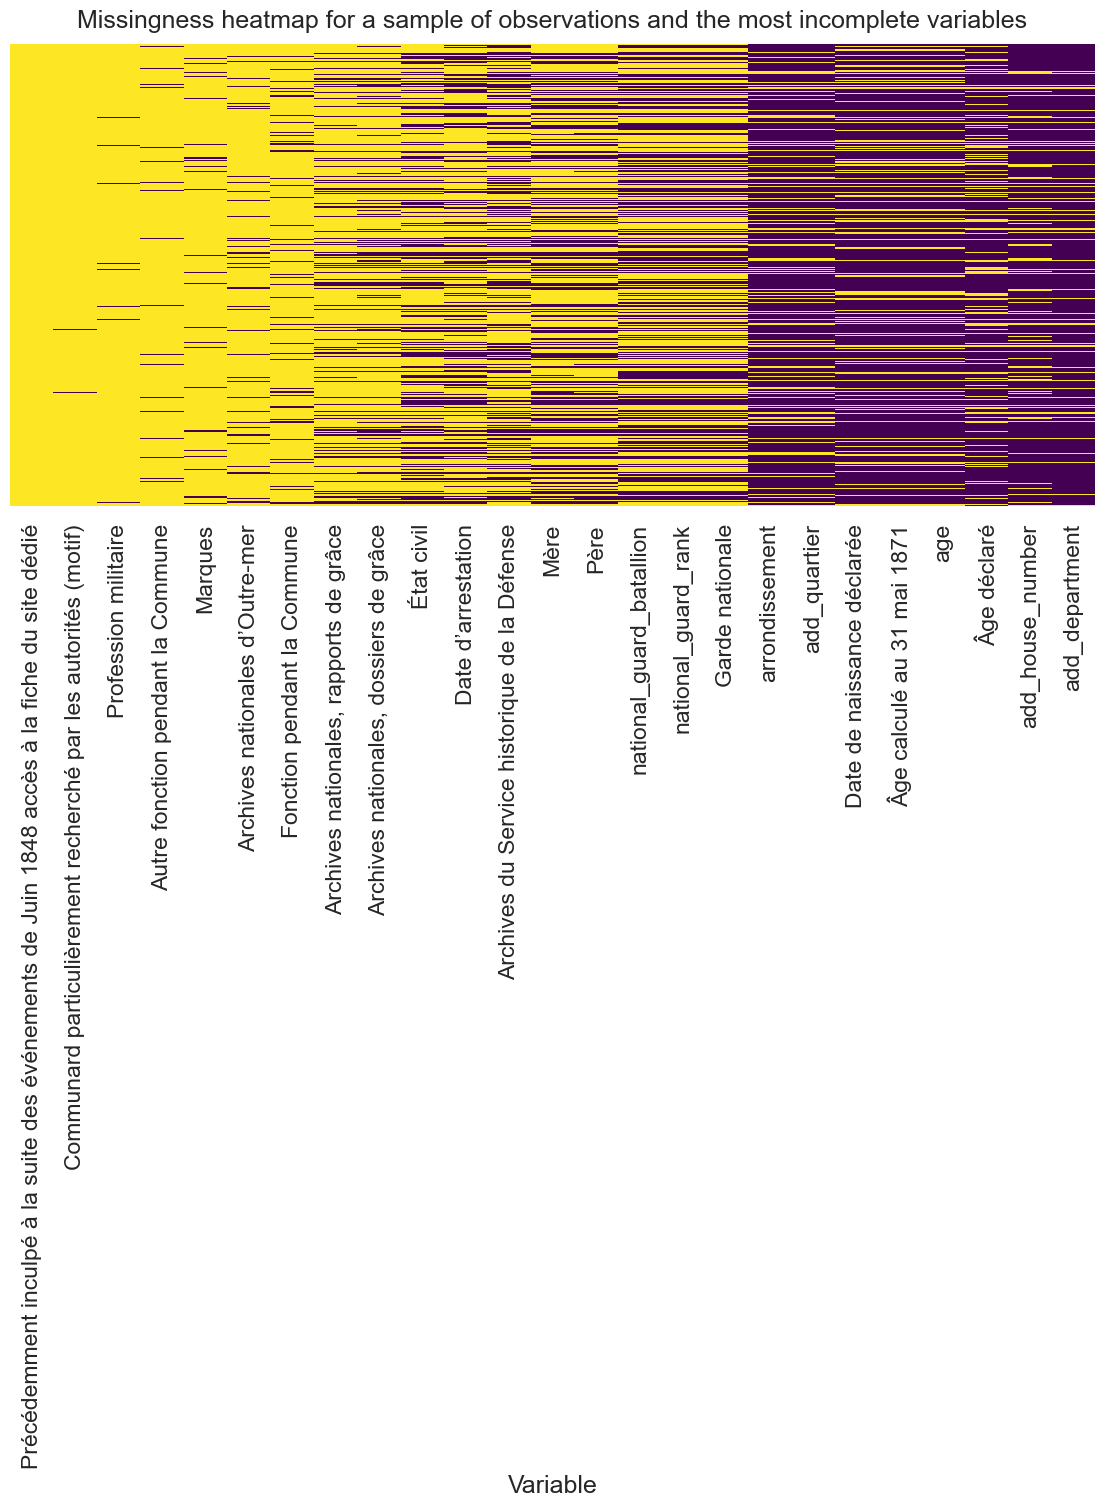

In [5]:
# Section 1: Load the dataset and inspect missingness

DATA_PATH = "data/paris_commune_dataset.csv"
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]} columns")
display(raw_df.head())

# Basic descriptives and missingness overview.
missing_share = raw_df.isna().mean().sort_values(ascending=False)
missing_table = pd.DataFrame(
    {
        "missing_count": raw_df.isna().sum(),
        "missing_share": missing_share,
    }
).sort_values("missing_share", ascending=False)
print("\nMissingness summary")
display(missing_table.head(25))

plt.figure(figsize=(10, 6))
missing_table.head(20)["missing_share"].sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top missingness rates by variable")
plt.xlabel("Share missing")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

sample_size = min(len(raw_df), 2500)
missing_sample = raw_df.sample(sample_size, random_state=42)
missing_cols = missing_table.head(25).index.tolist()
plt.figure(figsize=(14, 6))
sns.heatmap(missing_sample[missing_cols].isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missingness heatmap for a sample of observations and the most incomplete variables")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()

analysis_df = raw_df.copy()

In [6]:
# Section 1: Derived variables and summary tables

analysis_df = raw_df.copy()

# Use the most likely source column for the special-targeting indicator.
most_wanted_source = None
for candidate in [
    "Communard_particulièrement_recherché_par_les_autorités_(motif)",
    "Communard particulièrement recherché par les autorités (motif)",
]:
    if candidate in analysis_df.columns:
        most_wanted_source = candidate
        break
if most_wanted_source is None:
    raise KeyError("Could not find the column for special-targeting motives.")

analysis_df["arrest_date"] = pd.to_datetime(analysis_df["Date d’arrestation"], errors="coerce", dayfirst=True)
analysis_df["arrest_year"] = analysis_df["arrest_date"].dt.year
analysis_df["arrest_month"] = analysis_df["arrest_date"].dt.month

# Historical phases for the repression timeline.
def arrest_phase(date_value):
    if pd.isna(date_value):
        return np.nan
    if date_value < pd.Timestamp("1871-03-18"):
        return "pre-Commune"
    if date_value <= pd.Timestamp("1871-05-20"):
        return "during Commune"
    if date_value <= pd.Timestamp("1871-05-28"):
        return "Semaine sanglante"
    return "post-Commune"

analysis_df["arrest_phase"] = analysis_df["arrest_date"].apply(arrest_phase)
analysis_df["most_wanted"] = analysis_df[most_wanted_source].notna().astype(int)
analysis_df["occupational_class"] = analysis_df.apply(classify_occupational_class, axis=1)
analysis_df["geo_quality"] = analysis_df.apply(classify_geo_quality, axis=1)
analysis_df["rank_band"] = analysis_df["national_guard_rank"].map(rank_to_band)
analysis_df["age_centered"] = analysis_df["age"] - analysis_df["age"].mean()

print("Derived-variable coverage")
summary_derived = pd.DataFrame(
    {
        "missing": analysis_df[["arrest_date", "arrest_year", "arrest_month", "arrest_phase", "most_wanted", "occupational_class", "geo_quality", "rank_band"]].isna().sum(),
        "non_missing_share": 1 - analysis_df[["arrest_date", "arrest_year", "arrest_month", "arrest_phase", "most_wanted", "occupational_class", "geo_quality", "rank_band"]].isna().mean(),
    }
)
print(summary_derived.round(3))

print("\nCounts for key derived variables")
for col in ["arrest_phase", "most_wanted", "occupational_class", "geo_quality", "rank_band"]:
    print(f"\n{col}")
    display(analysis_df[col].value_counts(dropna=False).to_frame(name="count"))

print("\nSummary statistics for age and arrest date")
display(analysis_df[["age", "arrest_year", "arrest_month"]].describe(include="all").T)

Derived-variable coverage
                    missing  non_missing_share
arrest_date           27388              0.338
arrest_year           27388              0.338
arrest_month          27388              0.338
arrest_phase          27388              0.338
most_wanted               0              1.000
occupational_class        0              1.000
geo_quality               0              1.000
rank_band                 0              1.000

Counts for key derived variables

arrest_phase


,count
arrest_phase,
NaN,27388
Semaine sanglante,6534
post-Commune,5867
during Commune,1584
pre-Commune,2



most_wanted


,count
most_wanted,
0,41100
1,275



occupational_class


...

,count
geo_quality,
low,41375



rank_band


,count
rank_band,
unknown,24215
low,10031
high,5243
middle,1886



Summary statistics for age and arrest date


,count,mean,std,min,25%,50%,75%,max
age,29874.0,35.421470,11.244611,11.0,27.0,35.0,43.0,78.0
arrest_year,13987.0,1871.347037,1.093625,1871.0,1871.0,1871.0,1871.0,1879.0
arrest_month,13987.0,5.549939,1.589232,1.0,5.0,5.0,6.0,12.0


## Section 1 Interpretation

The derived variables are designed to make the later models transparent and reproducible. The key choices are the arrest-phase cut points, the occupation-class heuristic, and the geocoding-quality threshold; these should be inspected after execution and adjusted only if the coded categories clearly misclassify a substantial share of cases.

The point of this section is not only to clean the data, but also to make explicit which observations are excluded in later models because of missing age, occupation, arrest date, or geocoding information.

## Section 2: Age, Class, and "Most Wanted" Status

**Research question:**
> Are younger and more skilled communards more likely to be specially targeted by the authorities, net of arrondissement and National Guard role?

This section compares the age and class composition of the most-wanted group to everyone else and then estimates a logistic regression with arrondissement fixed effects.

In [7]:
# Section 2: Logistic regression with arrondissement fixed effects

logit_df = analysis_df.dropna(subset=["most_wanted", "age", "occupational_class", "national_guard_rank", "arrondissement"]).copy()
logit_df["age_centered"] = logit_df["age"] - logit_df["age"].mean()
logit_df["age_centered_sq"] = logit_df["age_centered"] ** 2

logit_formula = (
    "most_wanted ~ age_centered + age_centered_sq + C(occupational_class) + "
    "C(national_guard_rank) + C(arrondissement)"
)
logit_model = smf.glm(
    formula=logit_formula,
    data=logit_df,
    family=sm.families.Binomial(),
).fit(cov_type="HC1")

print(logit_model.summary())

odds_ratios = pd.DataFrame(
    {
        "odds_ratio": np.exp(logit_model.params),
        "ci_low": np.exp(logit_model.conf_int()[0]),
        "ci_high": np.exp(logit_model.conf_int()[1]),
        "p_value": logit_model.pvalues,
    }
).sort_values("odds_ratio", ascending=False)
print("\nOdds ratios with 95% confidence intervals")
print(odds_ratios.round(3))

age_10yr_effect = np.exp(-10 * logit_model.params.get("age_centered", 0.0))
print(f"\nA 10-year decrease in age is associated with a multiplicative change of {age_10yr_effect:.3f} in the odds of being most wanted, holding other factors constant.")

# Variance inflation diagnostics for the non-fixed-effect terms.
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_formula = "most_wanted ~ age_centered + age_centered_sq + C(occupational_class) + C(national_guard_rank)"
_, vif_X = dmatrices(vif_formula, data=logit_df, return_type="dataframe")
vif_rows = []
for idx, column in enumerate(vif_X.columns):
    if column == "Intercept":
        continue
    vif_rows.append({"term": column, "vif": variance_inflation_factor(vif_X.values, idx)})
vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
print("\nVariance inflation factors (excluding arrondissement fixed effects)")
print(vif_table.round(2))
print(f"\nCondition number of the fitted design matrix: {np.linalg.cond(logit_model.model.exog):.2f}")

NameError: name 'smf' is not defined

/var/folders/zp/r_synnss3dnc2lgwfbyr07h80000gn/T/ipykernel_14044/3261290396.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=logit_plot_df, x="most_wanted_label", y="age", inner="quartile", ax=axes[0], palette="Set2")


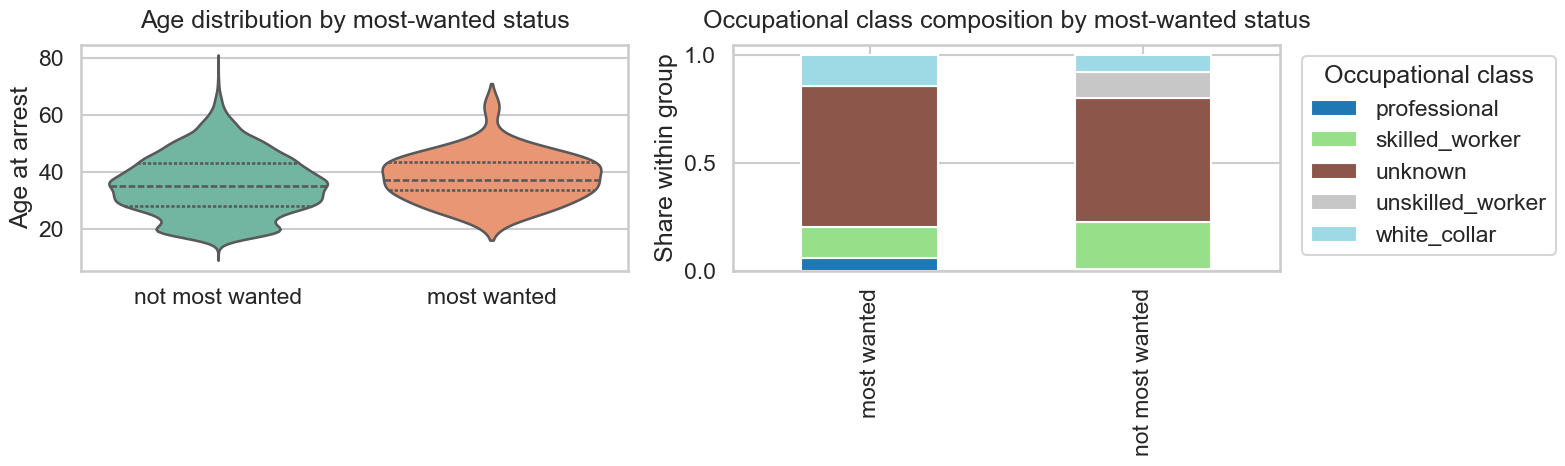

occupational_class  professional  skilled_worker  unknown  unskilled_worker  \
most_wanted_label                                                             
most wanted                    2               5       23                 0   
not most wanted               99            2806     7410              1586   

occupational_class  white_collar  
most_wanted_label                 
most wanted                    5  
not most wanted              963  


In [8]:
# Section 2: Bivariate exploration of age and class by most-wanted status

logit_plot_df = analysis_df.dropna(subset=["age", "occupational_class", "most_wanted", "national_guard_rank", "arrondissement"]).copy()
logit_plot_df["most_wanted_label"] = logit_plot_df["most_wanted"].map({0: "not most wanted", 1: "most wanted"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=logit_plot_df, x="most_wanted_label", y="age", inner="quartile", ax=axes[0], palette="Set2")
axes[0].set_title("Age distribution by most-wanted status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age at arrest")

class_share = pd.crosstab(logit_plot_df["most_wanted_label"], logit_plot_df["occupational_class"], normalize="index")
class_share[[c for c in class_share.columns if c in class_share.columns]].plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Occupational class composition by most-wanted status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share within group")
axes[1].legend(title="Occupational class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(pd.crosstab(logit_plot_df["most_wanted_label"], logit_plot_df["occupational_class"]))

## Section 2 Interpretation

The logistic model directly addresses whether younger and more occupationally privileged communards were more likely to be marked as especially wanted by the authorities. Odds ratios below 1 on age imply that younger individuals were more likely to be targeted, while class and rank coefficients show whether social position and military role mattered net of arrondissement fixed effects.

Because the model includes several categorical controls, some collinearity is expected mechanically. The notebook therefore reports variance-inflation diagnostics for the non-fixed-effect terms and interprets the estimated age effect in 10-year units for historical clarity.

## Section 3: Time-to-Arrest Analysis

**Research question:**
> Conditional on appearing in the judicial records, which characteristics are associated with earlier versus later arrest during the repression?

This section treats the arrest date as an event-history outcome measured from 18 March 1871, the common temporal origin of the Commune. The preferred model is a Cox proportional hazards specification, but the notebook falls back to a simpler linear model if survival-analysis libraries are unavailable.

In [9]:
# Section 3: Cox model or linear fallback

cox_ready_cols = ["time_to_arrest_days", "event", "age_centered", "occupational_class", "rank_band", "arrondissement"]
cox_df = survival_df.dropna(subset=cox_ready_cols).copy()

try:
    from lifelines import CoxPHFitter

    cph = CoxPHFitter()
    cox_formula = "age_centered + I(age_centered ** 2) + C(occupational_class) + C(rank_band) + C(arrondissement)"
    cph.fit(cox_df, duration_col="time_to_arrest_days", event_col="event", formula=cox_formula)
    print(cph.summary[["coef", "exp(coef)", "se(coef)", "p"]].round(4))

    try:
        cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
    except Exception as exc:
        print("Proportional hazards diagnostics were not fully available:", exc)

    hazard_table = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
    hazard_table.columns = ["hazard_ratio", "ci_low", "ci_high", "p_value"]
    print("\nHazard ratios with 95% confidence intervals")
    print(hazard_table.round(3))
except Exception as exc:
    print("lifelines was not available; using a linear regression on arrest date as a fallback.")
    print(exc)
    cox_df["arrest_ordinal"] = cox_df["arrest_date"].map(pd.Timestamp.toordinal)
    fallback_formula = "arrest_ordinal ~ age_centered + I(age_centered ** 2) + C(occupational_class) + C(rank_band) + C(arrondissement)"
    fallback_model = smf.ols(fallback_formula, data=cox_df).fit(cov_type="HC1")
    print(fallback_model.summary())

NameError: name 'survival_df' is not defined

In [10]:
# Section 3: Survival / event-history analysis

origin_date = pd.Timestamp("1871-03-18")
survival_df = analysis_df.copy()
survival_df["arrest_date"] = pd.to_datetime(survival_df["arrest_date"], errors="coerce")
survival_df = survival_df.loc[survival_df["arrest_date"].notna()].copy()
survival_df["time_to_arrest_days"] = (survival_df["arrest_date"] - origin_date).dt.days
survival_df = survival_df.loc[survival_df["time_to_arrest_days"] >= 0].copy()
survival_df["event"] = 1
survival_df["rank_band"] = survival_df["national_guard_rank"].map(rank_to_band)

# Compare occupational classes, high vs low rank, and a small set of high-volume arrondissements.
top_arrondissements = survival_df["arrondissement"].value_counts().head(6).index.tolist()
survival_df["arrondissement_group"] = survival_df["arrondissement"].where(
    survival_df["arrondissement"].isin(top_arrondissements),
    other=0,
)
survival_df["arrondissement_group"] = survival_df["arrondissement_group"].astype(int)

try:
    from lifelines import KaplanMeierFitter

    kmf = KaplanMeierFitter()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for cls, g in survival_df.dropna(subset=["occupational_class"]).groupby("occupational_class"):
        kmf.fit(g["time_to_arrest_days"], event_observed=g["event"], label=cls)
        kmf.plot(ax=axes[0])
    axes[0].set_title("Kaplan–Meier curves by occupational class")
    axes[0].set_xlabel("Days since 18 March 1871")
    axes[0].set_ylabel("Probability not yet arrested")

    for band, g in survival_df.dropna(subset=["rank_band"]).groupby("rank_band"):
        kmf.fit(g["time_to_arrest_days"], event_observed=g["event"], label=band)
        kmf.plot(ax=axes[1])
    axes[1].set_title("Kaplan–Meier curves by National Guard rank band")
    axes[1].set_xlabel("Days since 18 March 1871")
    axes[1].set_ylabel("Probability not yet arrested")

    for arr, g in survival_df.loc[survival_df["arrondissement"].isin(top_arrondissements)].groupby("arrondissement"):
        kmf.fit(g["time_to_arrest_days"], event_observed=g["event"], label=f"Arr. {arr}")
        kmf.plot(ax=axes[2])
    axes[2].set_title("Kaplan–Meier curves by selected arrondissements")
    axes[2].set_xlabel("Days since 18 March 1871")
    axes[2].set_ylabel("Probability not yet arrested")

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("lifelines was not available; survival curves are replaced by simple group means.")
    print(exc)
    survival_means = survival_df.groupby(["occupational_class", "rank_band"]) ["time_to_arrest_days"].mean().sort_values()
    display(survival_means.to_frame(name="mean_time_to_arrest_days"))

lifelines was not available; survival curves are replaced by simple group means.
No module named 'lifelines'


mean_time_to_arrest_days
occupational_class rank_band                          
unskilled_worker   low                       83.442582
unknown            low                       98.453618
professional       middle                   105.272727
skilled_worker     low                      105.650785
white_collar       low                      125.463519
unskilled_worker   unknown                  153.941909
                   middle                   176.774775
professional       low                      195.392857
unknown            middle                   228.611026
white_collar       middle                   241.572727
skilled_worker     middle                   255.827586
unknown            unknown                  256.320397
skilled_worker     unknown                  258.567568
professional       high                     387.931034
                   unknown                  428.911765
unskilled_worker   high                     470.921986
unknown            high                     487.935357
skilled_worker     high                     525.650259
white_collar       high                     540.343478
                   unknown                  542.046358

## Section 3 Interpretation

The event-history analysis should be read as a description of repression tempo among those already present in the judicial records. A hazard ratio above 1 means earlier arrest relative to the reference group, while a hazard ratio below 1 means later arrest.

If the proportional hazards assumptions look acceptable, the Cox model gives a compact way to compare arrest timing across occupational and organizational groups. If they do not, the notebook falls back to a simpler regression on arrest date while preserving the same substantive question.

## Section 4: Spatial Autocorrelation of Repression

**Research question:**
> Is repression spatially clustered across arrondissements, and how is it related to their socio-occupational composition?

The spatial section aggregates the individual records to the arrondissement level, then tests whether the resulting intensity surface shows more clustering than we would expect by chance. If a GeoJSON file is available locally, the notebook will also visualise the spatial pattern and compute local cluster diagnostics.

In [13]:
if arr_gdf is not None and arr_gdf.geometry.notna().any():
    try:
        from libpysal.weights import Queen
        from esda.moran import Moran, Moran_Local

        spatial_frame = arr_gdf.dropna(subset=["communard_count"]).copy()
        w = Queen.from_dataframe(spatial_frame)
        w.transform = "r"

        moran_global = Moran(spatial_frame["communard_count"], w)
        print(f"Global Moran's I: {moran_global.I:.3f}")
        print(f"Expected I under null: {moran_global.EI:.3f}")
        print(f"Permutation p-value: {moran_global.p_sim:.4f}")

        local_moran = Moran_Local(spatial_frame["communard_count"], w)
        spatial_frame["local_quadrant"] = local_moran.q
        spatial_frame["local_p"] = local_moran.p_sim

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        spatial_frame.plot(
            column="communard_count",
            cmap="OrRd",
            linewidth=0.5,
            edgecolor="white",
            legend=True,
            ax=ax,
        )
        ax.set_title("Communard counts by arrondissement")
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        cluster_colors = {1: "red", 2: "blue", 3: "lightblue", 4: "pink"}
        colors = spatial_frame["local_quadrant"].map(cluster_colors).fillna("lightgrey")
        spatial_frame.plot(color=colors, linewidth=0.5, edgecolor="white", ax=ax)
        ax.set_title("Local Moran quadrants (red = high-high, blue = low-low)")
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

        print("\nArrondissements with the strongest high-high clustering")
        display(spatial_frame.loc[spatial_frame["local_quadrant"] == 1, ["arrondissement", "communard_count", "local_p"]].sort_values("local_p").head(10))
    except Exception as exc:
        print("Spatial autocorrelation libraries were not available or failed to run:")
        print(exc)
        arr_agg["spatial_lag_intensity"] = np.nan
else:
    print("No arrondissement geometry was loaded, so Moran's I and spatial clustering are skipped.")

# Fallback spatial-style regression if geometry or spatial packages are unavailable.
if "spatial_frame" in locals() and "w" in locals():
    arr_for_model = spatial_frame.copy()
    try:
        from libpysal.weights.spatial_lag import lag_spatial
        arr_for_model["spatial_lag_intensity"] = lag_spatial(w, arr_for_model["communard_count"].to_numpy())
    except Exception:
        arr_for_model["spatial_lag_intensity"] = np.nan
else:
    arr_for_model = arr_agg.copy()
    arr_for_model["spatial_lag_intensity"] = np.nan

spatial_model_df = arr_for_model.dropna(subset=["communard_count", "skilled_share", "unskilled_share", "mean_age", "most_wanted_share"]).copy()
if spatial_model_df["spatial_lag_intensity"].notna().any():
    spatial_formula = "communard_count ~ skilled_share + unskilled_share + mean_age + most_wanted_share + spatial_lag_intensity"
else:
    spatial_formula = "communard_count ~ skilled_share + unskilled_share + mean_age + most_wanted_share"

spatial_model = smf.ols(spatial_formula, data=spatial_model_df).fit(cov_type="HC1")
print("\nSpatial regression / contextual OLS")
print(spatial_model.summary())

No arrondissement geometry was loaded, so Moran's I and spatial clustering are skipped.


NameError: name 'smf' is not defined

In [12]:
# Section 4: Spatial autocorrelation and spatial regression

arr_agg = (
    analysis_df.groupby("arrondissement")
    .agg(
        communard_count=("age", "size"),
        mean_age=("age", "mean"),
        skilled_share=("occupational_class", lambda s: (s == "skilled_worker").mean()),
        unskilled_share=("occupational_class", lambda s: (s == "unskilled_worker").mean()),
        most_wanted_share=("most_wanted", "mean"),
    )
    .reset_index()
)

arr_gdf = None
geo_candidates = [
    Path("data/paris_arrondissements.geojson"),
    Path("data/paris_arrondissements.gpkg"),
    Path("data/paris_arrondissements.shp"),
]
for candidate in geo_candidates:
    if candidate.exists():
        try:
            arr_gdf = gpd.read_file(candidate)
            print(f"Loaded arrondissement geometry from {candidate}")
            break
        except Exception as exc:
            print(f"Could not load {candidate}: {exc}")

if arr_gdf is not None:
    possible_key_cols = [
        col for col in arr_gdf.columns
        if col.lower() in {"arrondissement", "arrond", "district", "number", "id"}
        or "arrond" in col.lower()
        or "district" in col.lower()
    ]
    if possible_key_cols:
        key_col = possible_key_cols[0]
        arr_gdf["arrondissement"] = pd.to_numeric(arr_gdf[key_col], errors="coerce")
        arr_gdf = arr_gdf.merge(arr_agg, on="arrondissement", how="left")
    else:
        print("Loaded geometry, but could not identify the arrondissement key column.")
        print(arr_gdf.columns.tolist())

arr_agg.head()

,arrondissement,communard_count,mean_age,skilled_share,unskilled_share,most_wanted_share
0,1.0,754,34.390523,0.163130,0.152520,0.011936
1,2.0,750,33.942664,0.141333,0.150667,0.006667
2,3.0,1244,34.000942,0.129421,0.107717,0.005627
3,4.0,1620,33.717143,0.238889,0.109877,0.004938
4,5.0,1608,35.475655,0.269900,0.111940,0.006219


## Section 4 Interpretation

If repression is spatially clustered, one should see both a non-random choropleth pattern and positive global Moran's I. High-high local clusters would indicate that adjacent arrondissements share similarly intense repression, whereas low-low clusters would suggest spatial pockets of relative leniency or weaker record concentration.

The regression stage then asks whether arrondissement-level repression is better explained by local social composition or by a diffusion-style spatial lag. A stronger fit for composition variables would support a local-structure account; a strong spatial lag would suggest contagion across nearby districts.

## Section 5 Interpretation

The battalion analysis should be read as a test of territoriality rather than a strict reconstruction of military organization. If most battalions are strongly concentrated in one arrondissement, that supports a residential pattern. If several battalions have substantial outside-modal shares, that suggests cross-district ties and a looser relationship between residence and organizational membership.

The individual-level logit then asks whether battalion cross-districtness is associated with distinct age or class profiles. Substantive differences here would be consistent with the idea that certain units integrated more heterogeneous social and spatial networks.

In [14]:
# Section 5: Individual model of cross-district battalion membership

battalion_model_df = battalion_df.dropna(subset=["cross_district_battalion", "age_centered", "occupational_class", "national_guard_rank", "arrondissement"]).copy()

battalion_formula = (
    "cross_district_battalion ~ age_centered + I(age_centered ** 2) + C(occupational_class) + "
    "C(national_guard_rank) + C(arrondissement)"
)
battalion_model = smf.glm(
    formula=battalion_formula,
    data=battalion_model_df,
    family=sm.families.Binomial(),
).fit(cov_type="cluster", cov_kwds={"groups": battalion_model_df["national_guard_batallion"]})

battalion_or = pd.DataFrame(
    {
        "odds_ratio": np.exp(battalion_model.params),
        "ci_low": np.exp(battalion_model.conf_int()[0]),
        "ci_high": np.exp(battalion_model.conf_int()[1]),
        "p_value": battalion_model.pvalues,
    }
).sort_values("odds_ratio", ascending=False)

print("Cross-district battalion model with clustered standard errors")
print(battalion_or.round(3).head(15))

print("\nInterpretive note: if the occupational coefficients are small while age and rank remain stable, battalion territoriality is likely organized more by local recruitment patterns than by social class alone.")

NameError: name 'battalion_df' is not defined

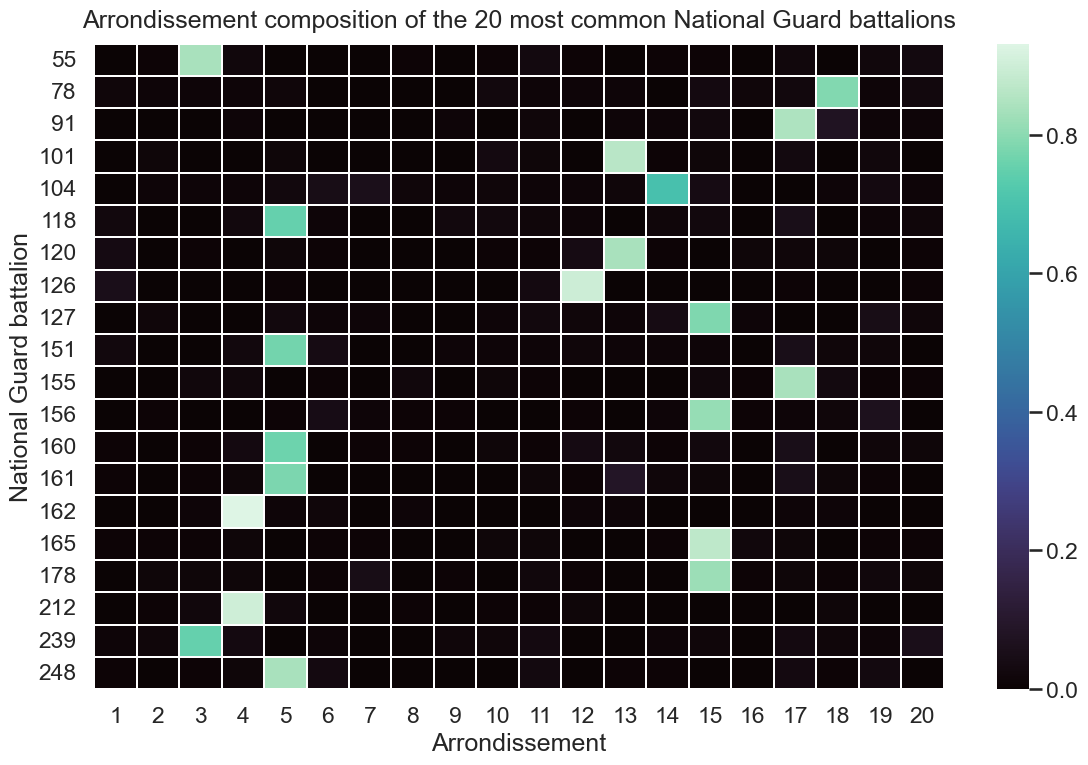

Top 10 battalions by outside-modal share


,national_guard_batallion,n_members,modal_arrondissement,outside_modal_share,mean_age,skilled_share,unskilled_share,cross_district_battalion
1,2,16.0,2.0,0.875000,33.500000,0.250000,0.187500,True
262,268,45.0,15.0,0.866667,27.454545,0.155556,0.155556,True
264,270,42.0,18.0,0.857143,28.238095,0.095238,0.285714,True
250,252,12.0,2.0,0.833333,33.111111,0.083333,0.333333,True
13,14,6.0,2.0,0.833333,36.166667,0.166667,0.333333,True
233,235,5.0,3.0,0.800000,38.400000,0.000000,0.000000,True
266,272,5.0,2.0,0.800000,36.750000,0.000000,0.200000,True
11,12,30.0,3.0,0.800000,29.888889,0.133333,0.266667,True
97,99,33.0,12.0,0.787879,31.272727,0.424242,0.151515,True
96,98,32.0,4.0,0.781250,34.296296,0.125000,0.093750,True


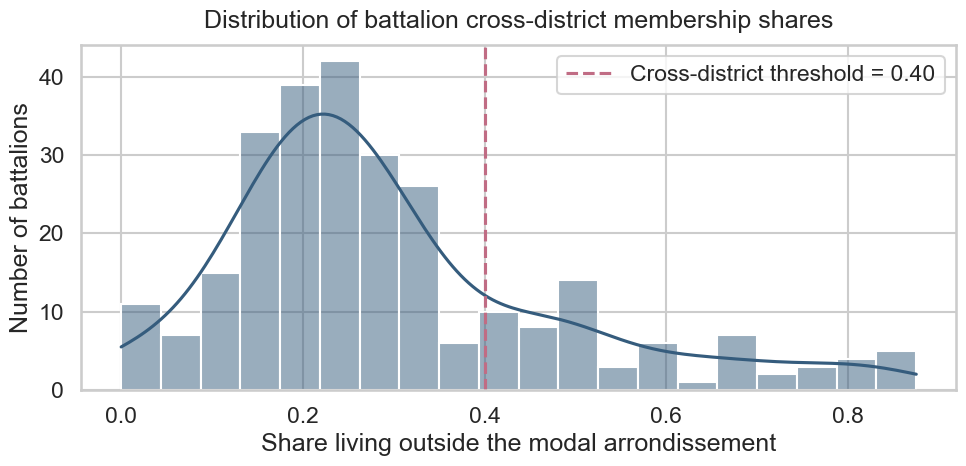

Battalions flagged as cross-district: 61


In [15]:
# Section 5: Battalion composition and cross-district units

battalion_df = analysis_df.copy()
battalion_df = battalion_df.loc[battalion_df["national_guard_batallion"].notna() & battalion_df["arrondissement"].notna()].copy()
battalion_df["national_guard_batallion"] = battalion_df["national_guard_batallion"].astype(int)
battalion_df["arrondissement"] = battalion_df["arrondissement"].astype(int)

# Focus on the most common battalions to keep the heatmap legible.
top_battalions = battalion_df["national_guard_batallion"].value_counts().head(20).index
battalion_panel = battalion_df.loc[battalion_df["national_guard_batallion"].isin(top_battalions)].copy()

battalion_arr_crosstab = pd.crosstab(
    battalion_panel["national_guard_batallion"],
    battalion_panel["arrondissement"],
    normalize="index",
)

plt.figure(figsize=(12, 8))
sns.heatmap(battalion_arr_crosstab, cmap="mako", linewidths=0.3)
plt.title("Arrondissement composition of the 20 most common National Guard battalions")
plt.xlabel("Arrondissement")
plt.ylabel("National Guard battalion")
plt.tight_layout()
plt.show()

battalion_summary = (
    battalion_df.groupby("national_guard_batallion")
    .apply(
        lambda g: pd.Series(
            {
                "n_members": len(g),
                "modal_arrondissement": g["arrondissement"].mode().iat[0],
                "modal_share": g["arrondissement"].value_counts(normalize=True).iat[0],
                "outside_modal_share": 1 - g["arrondissement"].value_counts(normalize=True).iat[0],
                "mean_age": g["age"].mean(),
                "skilled_share": (g["occupational_class"] == "skilled_worker").mean(),
                "unskilled_share": (g["occupational_class"] == "unskilled_worker").mean(),
            }
        )
    )
    .reset_index()
)

cross_threshold = 0.40
battalion_summary["cross_district_battalion"] = battalion_summary["outside_modal_share"] > cross_threshold

print("Top 10 battalions by outside-modal share")
display(
    battalion_summary.sort_values("outside_modal_share", ascending=False)
    .head(10)
    [["national_guard_batallion", "n_members", "modal_arrondissement", "outside_modal_share", "mean_age", "skilled_share", "unskilled_share", "cross_district_battalion"]]
)

plt.figure(figsize=(10, 5))
sns.histplot(battalion_summary["outside_modal_share"], bins=20, kde=True, color="#355C7D")
plt.axvline(cross_threshold, color="#C06C84", linestyle="--", label=f"Cross-district threshold = {cross_threshold:.2f}")
plt.title("Distribution of battalion cross-district membership shares")
plt.xlabel("Share living outside the modal arrondissement")
plt.ylabel("Number of battalions")
plt.legend()
plt.tight_layout()
plt.show()

# Merge battalion-level indicator back to individuals for an individual-level model.
battalion_df = battalion_df.merge(
    battalion_summary[["national_guard_batallion", "cross_district_battalion"]],
    on="national_guard_batallion",
    how="left",
)

print("Battalions flagged as cross-district:", battalion_summary["cross_district_battalion"].sum())

## Section 5: Battalions, Arrondissements, and Network Structure

**Research question:**
> Do battalion-number patterns support the idea of territorially based legions, and can we identify battalions whose membership is unusually cross-district?

This section treats battalions as the relevant organizational unit and asks whether they are mostly local to one arrondissement or instead draw members from multiple districts. That distinction is useful for evaluating whether repression reflects neighborhood-based recruitment or broader cross-district ties.

In [16]:
# Section 6: Multilevel model / fixed-effects approximation

multilevel_df = analysis_df.copy()
multilevel_df["mean_arrondissement_age"] = multilevel_df.groupby("arrondissement")["age"].transform("mean")
multilevel_df["skill_share_arrondissement"] = multilevel_df.groupby("arrondissement")["occupational_class"].transform(
    lambda s: (s == "skilled_worker").mean()
)
multilevel_df["low_skill_share_arrondissement"] = multilevel_df.groupby("arrondissement")["occupational_class"].transform(
    lambda s: (s == "unskilled_worker").mean()
)

context_formula = (
    "most_wanted ~ age_centered + I(age_centered ** 2) + C(occupational_class) + C(national_guard_rank)"
)
context_model_1 = smf.glm(
    formula=context_formula,
    data=multilevel_df.dropna(subset=["most_wanted", "age_centered", "occupational_class", "national_guard_rank", "arrondissement"]),
    family=sm.families.Binomial(),
).fit(cov_type="HC1")

context_formula_2 = context_formula + " + mean_arrondissement_age + skill_share_arrondissement + low_skill_share_arrondissement"
context_model_2 = smf.glm(
    formula=context_formula_2,
    data=multilevel_df.dropna(subset=["most_wanted", "age_centered", "occupational_class", "national_guard_rank", "arrondissement", "mean_arrondissement_age", "skill_share_arrondissement", "low_skill_share_arrondissement"]),
    family=sm.families.Binomial(),
).fit(cov_type="HC1")

print("Model 1: individual-level predictors only")
print(context_model_1.summary().tables[1])
print("\nModel 2: individual + arrondissement-level context")
print(context_model_2.summary().tables[1])

model_comparison = pd.DataFrame(
    {
        "AIC": [context_model_1.aic, context_model_2.aic],
        "BIC": [context_model_1.bic, context_model_2.bic],
        "Pseudo_R2_McFadden": [
            1 - context_model_1.llf / context_model_1.llnull,
            1 - context_model_2.llf / context_model_2.llnull,
        ],
    },
    index=["Individual only", "Individual + context"],
)
print("\nModel comparison")
print(model_comparison.round(3))

# Approximate the ICC from a random-intercept model if Bayesian mixed GLM is available.
try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

    bayes_data = multilevel_df.dropna(subset=["most_wanted", "age_centered", "occupational_class", "national_guard_rank", "arrondissement"]).copy()
    variance_formula = {"arrondissement": "0 + C(arrondissement)"}
    bayes_model = BinomialBayesMixedGLM.from_formula(
        "most_wanted ~ age_centered + I(age_centered ** 2) + C(occupational_class) + C(national_guard_rank)",
        variance_formula,
        bayes_data,
    )
    bayes_result = bayes_model.fit_vb()
    arrondissement_sd = float(np.exp(bayes_result.vcp_mean[0]))
    arrondissement_var = arrondissement_sd ** 2
    icc = arrondissement_var / (arrondissement_var + (np.pi ** 2) / 3)
    print(f"\nApproximate random-intercept SD: {arrondissement_sd:.3f}")
    print(f"Approximate ICC: {icc:.3f}")
except Exception as exc:
    print("\nBayesian mixed-effects fit was not available; using the fixed-effects approximation instead.")
    print("Reason:", exc)
    fe_formula = context_formula + " + C(arrondissement)"
    fe_model = smf.glm(
        formula=fe_formula,
        data=multilevel_df.dropna(subset=["most_wanted", "age_centered", "occupational_class", "national_guard_rank", "arrondissement"]),
        family=sm.families.Binomial(),
    ).fit(cov_type="HC1")
    print(fe_model.summary().tables[1])

NameError: name 'smf' is not defined

## Section 6: Joint Effects of Age, Class, and Space on Repression Intensity

**Research question:**
> To what extent do individual-level characteristics versus arrondissement-level context explain variation in being specially targeted by the authorities?

The preferred specification is a multilevel logistic model with individuals nested in arrondissements. If a suitable mixed-effects estimator is unavailable in the runtime, the notebook falls back to a fixed-effects approximation and reports the change in model fit when arrondissement-level contextual variables are added.

## Section 7: Robustness & Sensitivity Analyses

**Research question:**
> Are the key results stable if we recode occupation more conservatively, restrict to high-quality geocoded observations, and inspect influential cases?

This section treats the main logistic specification as the reference model and then re-estimates it under two perturbations: a stricter occupational taxonomy and a high-confidence geocoding subset. It also checks whether a small number of observations exert disproportionate leverage on the fitted model.

In [17]:
# Section 7: Robustness and Sensitivity Analyses

# Alternative occupational coding for robustness.
def occupation_class_v2(row):
    text = " ".join(
        str(row.get(col, "") or "").lower()
        for col in ["Branche", "Type d'activité", "Profession civile"]
    )
    if any(term in text for term in ["avocat", "docteur", "médecin", "professeur", "ingénieur", "architecte", "journaliste", "notaire", "magistrat"]):
        return "professional"
    if any(term in text for term in ["employ", "commis", "bureau", "comptable", "négociant", "vendeur", "caissier"]):
        return "white_collar"
    if any(term in text for term in ["ouvrier", "artisan", "tailleur", "menuis", "charpent", "serrurier", "imprimeur", "cordonn", "maçon", "peintre", "typograph", "forgeron", "ébénist", "blanchiss", "hatter", "painter"]):
        return "skilled_worker"
    if any(term in text for term in ["manœuvre", "journalier", "journali", "domestique", "porteur", "charretier", "terrassier", "débardeur", "ouvrier"]):
        return "unskilled_worker"
    return "unknown"

robust_df = analysis_df.copy()
robust_df["occupational_class_v2"] = robust_df.apply(occupation_class_v2, axis=1)

robust_subset = robust_df.loc[robust_df["geo_quality"] == "high"].copy()
print(f"High geocoding quality subset: {len(robust_subset):,} observations")

robust_formula = (
    "most_wanted ~ age_centered + I(age_centered ** 2) + C(occupational_class_v2) + "
    "C(national_guard_rank) + C(arrondissement)"
)
robust_model = smf.glm(
    formula=robust_formula,
    data=robust_subset.dropna(subset=["most_wanted", "age_centered", "occupational_class_v2", "national_guard_rank", "arrondissement"]),
    family=sm.families.Binomial(),
).fit(cov_type="HC1")

robust_or = pd.DataFrame(
    {
        "odds_ratio": np.exp(robust_model.params),
        "ci_low": np.exp(robust_model.conf_int()[0]),
        "ci_high": np.exp(robust_model.conf_int()[1]),
        "p_value": robust_model.pvalues,
    }
).sort_values("odds_ratio", ascending=False)
print("\nRobustness check: alternative occupation coding on high-quality geocoded subset")
print(robust_or.round(3).head(15))

# Influence diagnostics for the main logistic model, if available.
try:
    influence = logit_model.get_influence()
    cooks = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    influence_frame = (
        analysis_df.loc[logit_model.model.data.row_labels, ["age", "occupational_class", "arrondissement", "most_wanted"]]
        .assign(cooks_distance=cooks, leverage=leverage)
        .sort_values("cooks_distance", ascending=False)
    )
    print("\nTop 10 observations by Cook's distance")
    display(influence_frame.head(10))
except Exception as exc:
    print("Influence diagnostics were not available for this fitted model:", exc)

print("\nSensitivity interpretation notes:")
print("1. Compare the sign and magnitude of age and occupational-class effects to the main model.")
print("2. Check whether the high-quality geocoding subset materially changes the estimates.")
print("3. Inspect whether the largest Cook's-distance observations are isolated cases or patterned by arrondissement or rank.")

High geocoding quality subset: 0 observations


NameError: name 'smf' is not defined

# Final Summary

This notebook closes with a synthesis of the main empirical patterns recovered across the sections above. After execution, use this section to summarise how repression varied by age, occupational class, spatial context, and National Guard organization, and to restate the main historical interpretation in compact form.

The analysis is designed to speak to three linked themes in historical sociology: selective repression, spatial unevenness, and the structure of social ties embedded in battalions. The strongest claims should be read with caution because the dataset is archival and selective, and because some operationalisations (especially occupation coding and battalion territoriality) are necessarily approximate.

Potential extensions include linking these records to census microdata or mortality registers, and assembling more precise measures of battalion geography, volunteer status, and post-Commune trajectories.